## Biological question

In this assignment, you will strive to build a representation that distinguishes the T cells (a core immune subset) in breast cancer versus normal breast tissues.

## Libraries

Here are some common libraries you'll probably want to use. [Scanpy](https://scanpy.readthedocs.io/en/stable/index.html) is a common library for analyzing single-cell RNA-seq (and a [classic tutorial on 3K cells](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html)). [AnnData](https://anndata.readthedocs.io/en/latest/) is a common data format. Feel free to use others as well.
For the AutoEncoder use pytorch.

In [ ]:
!pip install -r ./requirements.txt

In [1]:
##NEW
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import scanpy as sc

{p.__name__: p.__version__ for p in [ad, sc]}

{'anndata': '0.11.4', 'scanpy': '1.11.1'}

## Dataset

The dataset you'll be examining is a subset of data from [Kumar et al. (2023) Nature](https://www.nature.com/articles/s41586-023-06252-9) ([PDF](./s41586-023-06252-9.pdf)), whose data is available via CZI's cellxgene portal ([publication data link](https://cellxgene.cziscience.com/collections/4195ab4c-20bd-4cd3-8b3d-65601277e731)).

You will work with the "scRNA-seq data - T cells" subset (76,567 cells). You can download it into AnnData's h5ad format (~425 MB) by clicking the "Download" button next to it and copy-pasting a link like the following (though you should replace the below link with a fresh one given to you by the website).

In [ ]:
!curl -o dataset.h5ad "https://datasets.cellxgene.cziscience.com/a87890d9-bf31-4043-a3b7-1b46df89d8ff.h5ad"

In [3]:
adata = ad.read_h5ad('./data/dataset.h5ad')
adata.shape

(76567, 33145)

We see that we have ~76.5K cells across ~33K genes. The (sparse) gene expression data is stored in the `X` variable:

In [4]:
adata.X.shape, adata.X.dtype, adata.X.__class__

((76567, 33145), dtype('float32'), scipy.sparse._csr.csr_matrix)

We also have metadata for each individual cell:

In [5]:
adata.obs.head(3)

,mapped_reference_assembly,mapped_reference_annotation,alignment_software,donor_id,self_reported_ethnicity_ontology_term_id,donor_living_at_sample_collection,donor_menopausal_status,organism_ontology_term_id,sample_uuid,sample_preservation_method,...,reported_diseases,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
r1_hbca_c01_CTAGTGAGTACTCAAC,GRCh38,GENCODE 28,Cell Ranger count v3.1.0,P01,HANCESTRO:0005,True,postmenopausal,NCBITaxon:9606,c4a63080-974c-4eb1-9c40-7c6f93f65de6,n/a (fresh),...,breast cancer,mature NK T cell,10x 3' v2,normal,Homo sapiens,female,breast,European,adult stage,ql=%!_ZqPi
r1_hbca_c03_ACGATACGTACCAGTT,GRCh38,GENCODE 28,Cell Ranger count v3.1.0,P02,HANCESTRO:0005,True,premenopausal,NCBITaxon:9606,65eb6de4-ee12-436b-9c8e-0791e09fd88d,n/a (fresh),...,breast cancer,"effector memory CD8-positive, alpha-beta T cell",10x 3' v2,normal,Homo sapiens,female,breast,European,prime adult stage,d?|_T^;32!
r1_hbca_c03_AGCCTAAAGCGTCAAG,GRCh38,GENCODE 28,Cell Ranger count v3.1.0,P02,HANCESTRO:0005,True,premenopausal,NCBITaxon:9606,65eb6de4-ee12-436b-9c8e-0791e09fd88d,n/a (fresh),...,breast cancer,"effector memory CD8-positive, alpha-beta T cell",10x 3' v2,normal,Homo sapiens,female,breast,European,prime adult stage,>C<wMHASXf


Some of the most interesting metadata are
- `cell_type`
- `sample_id`
- `donor_id`
- `assay`
- `disease` or 'reported_diseases' (notice that they were having data curation issues with the disease column in which every cell seemed normal
- `development_stage`

You can look at the number of cells for each metadata value of a given column via

In [6]:
adata.obs['disease'].value_counts() 
#adata.obs['reported_diseases'].value_counts()  # in case disease doesn't work

disease
normal    76567
Name: count, dtype: int64

In [30]:

##NEW 
#Additional Imports
import pandas as pd
import numpy as np
import seaborn as sns

from external_api.LLM import get_llm
from external_api.gene_info import get_gene_info
from plots import create_hist, plot_categorical_distribution,plot_heatmap, plot_bar_comaprision
from utils import calc_batch_effect_score



## Exploratory data analysis

Explore the data. You can use some of the common workflows in the [Scanpy tutorial](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html) as well as anything else you'd like to see. Some common questions are:
- Should we filter down what genes to look at? If so, how should we do it?
- How much between-donor heterogeneity is there in the cell type abundance?
- Are there big differences in effect from samples from different `assay` types?

Some other things to keep in mind:
- The number of UMI counts (over all the genes) for each cell will varies and is not interesting in and of itself.
- The number of cells will be different for each `sample_id`, but this doesn't really mean anything.

In [8]:
##NEW
#Global Initializations

# Initialize the API client
llm_instance = get_llm('openai')

gene_info_instance = get_gene_info('my_gene_info',key='ensembl',species='human')


In [9]:
##NEW
#configuring Scanpy to display detailed logs, prints system and version info, and sets default figure appearance for plots.
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white")

**Gene Deduplication**

Check duplicate genes in data, if there any duplicate names, make them unique

In [10]:
def check_duplicates_in_gene_names(adata):
    # Find duplicated gene names
    duplicates = adata.var_names[adata.var_names.duplicated()]
    # Count and display
    print(f"Number of duplicated gene names: {duplicates.size}")
    print("Duplicated gene names:")
    print(duplicates.value_counts())
    return duplicates.size
    
num_duplicates = check_duplicates_in_gene_names(adata)
if num_duplicates > 0:
    adata.var_names_make_unique()
    _ = check_duplicates_in_gene_names(adata)
    


Number of duplicated gene names: 0
Duplicated gene names:
Series([], Name: count, dtype: int64)


**Highest expresed genes**

plots the 20 highest expressed genes across all cells in the data

Check their category.

In [33]:
##NEW
n_top = 20

def get_top_expressed_genes(adata, n_top):
    # Mean expression per gene
    mean_expression = np.asarray(adata.X.mean(axis=0)).flatten()

    # Top expressed genes
    top_genes_df = pd.DataFrame({
        'gene': adata.var_names,
        'mean_expression': mean_expression
    }).sort_values(by='mean_expression', ascending=False).iloc[:n_top]
    return top_genes_df['gene'].tolist()

top_genes = get_top_expressed_genes(adata, n_top)

##Plot highest expressed genes
sc.pl.highest_expr_genes(adata, n_top=n_top)

# Query multiple genes and request GO terms + summary + pathways
annotations = gene_info_instance.query_genes(top_genes,return_info='name,symbol')#'go.summary,pathway,summary')
results_df = gene_info_instance.parse_results(annotations)
results_df[['ensembl.gene','name']].head(n_top)
# answer = llm_instance.ask("What can u say on my top expressed genes? {}".format(results_df[['ensembl.gene','name']]))
# print(answer)

    



**Should we filter down what genes to look at? If so, how should we do it?**

We plan to examine the distribution of gene expression across cells, total counts per gene and per cell, and the percentage of counts attributed to mitochondrial and ribosomal genes — and apply filtering based on these metrics.

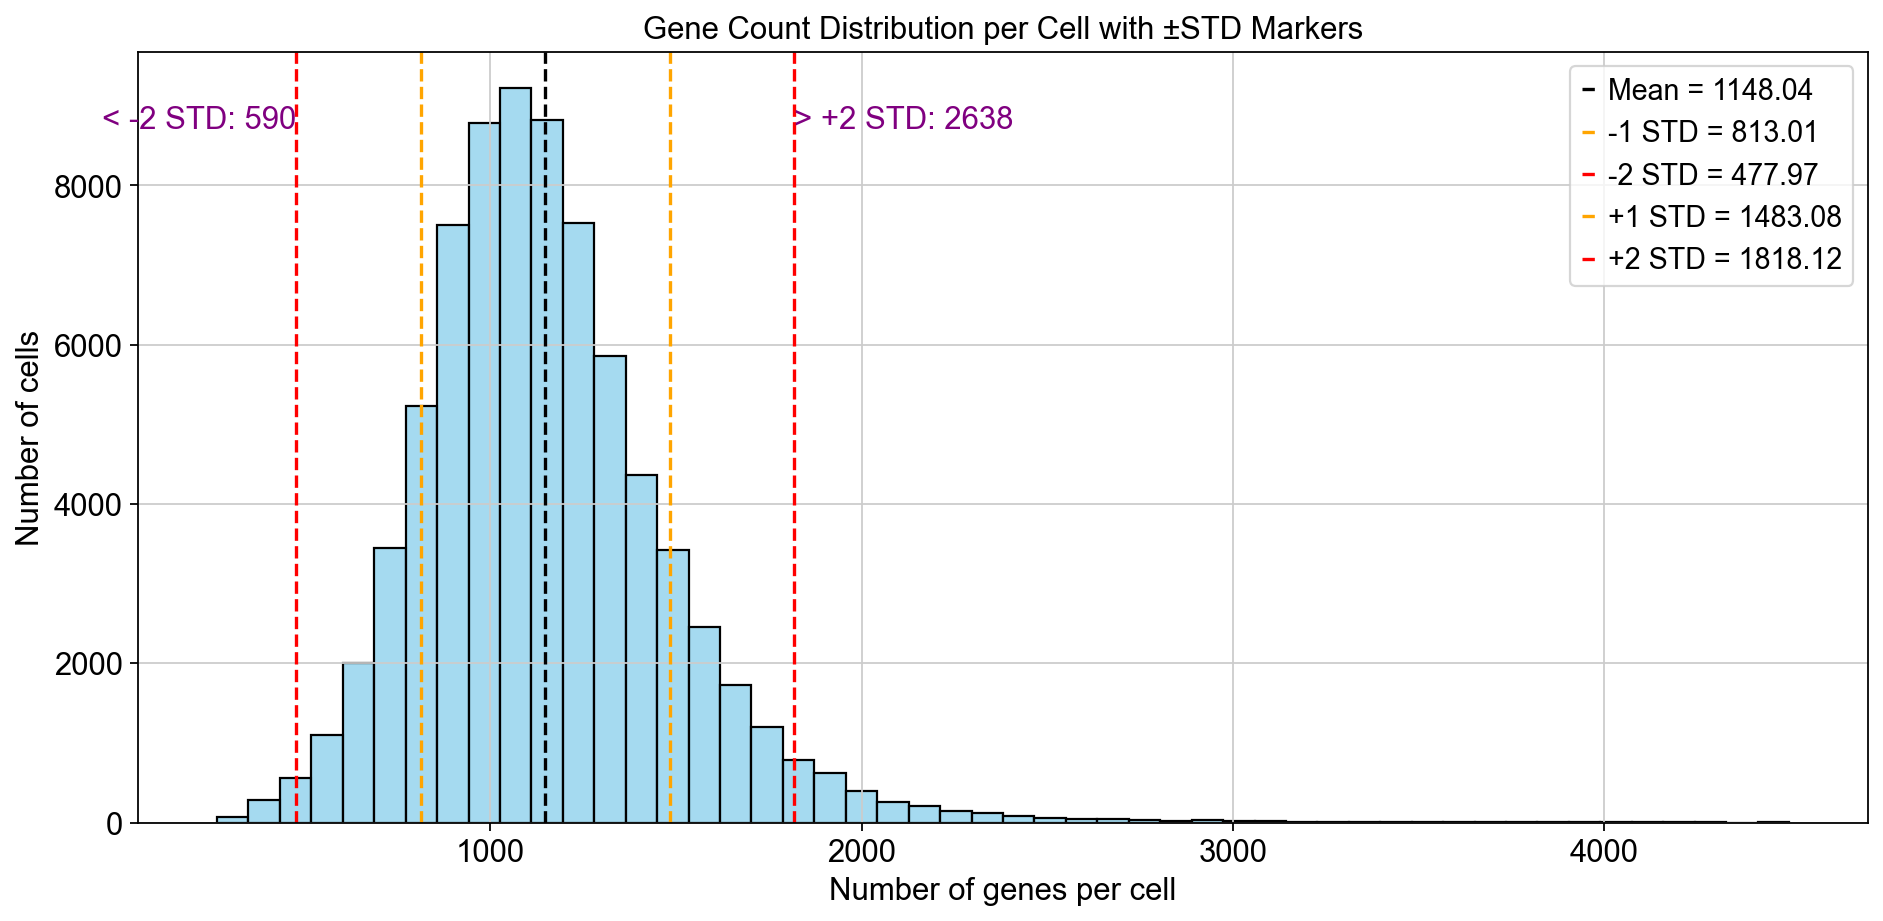

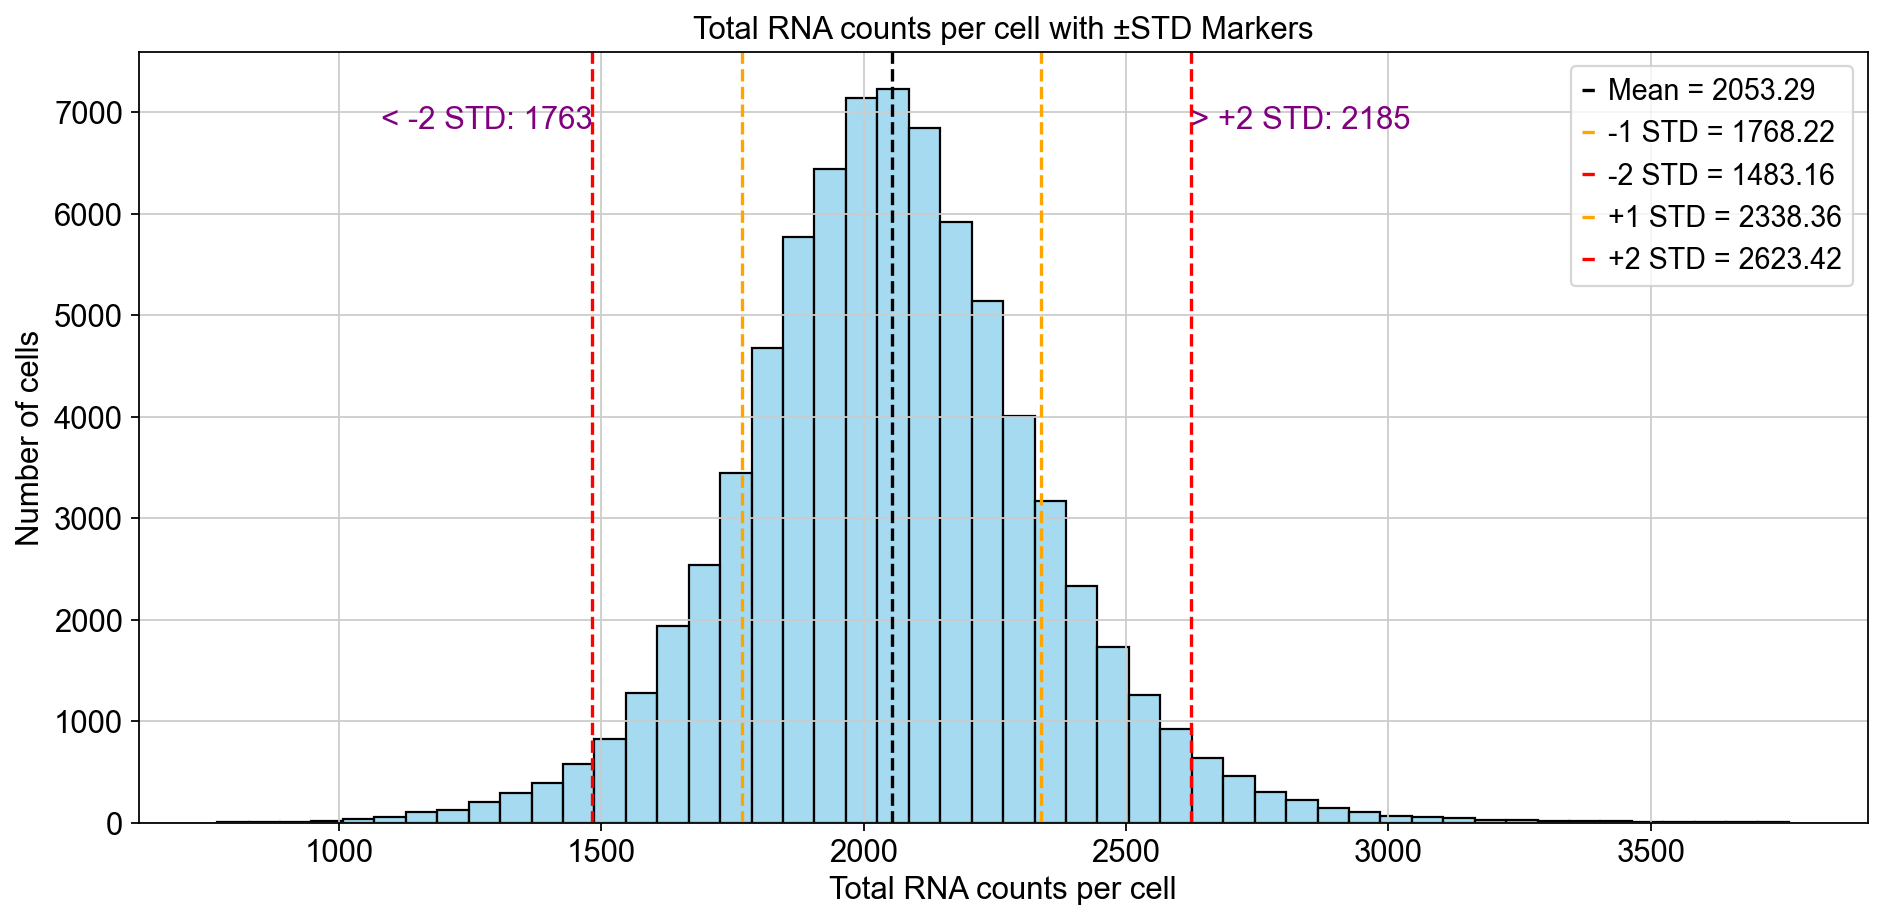

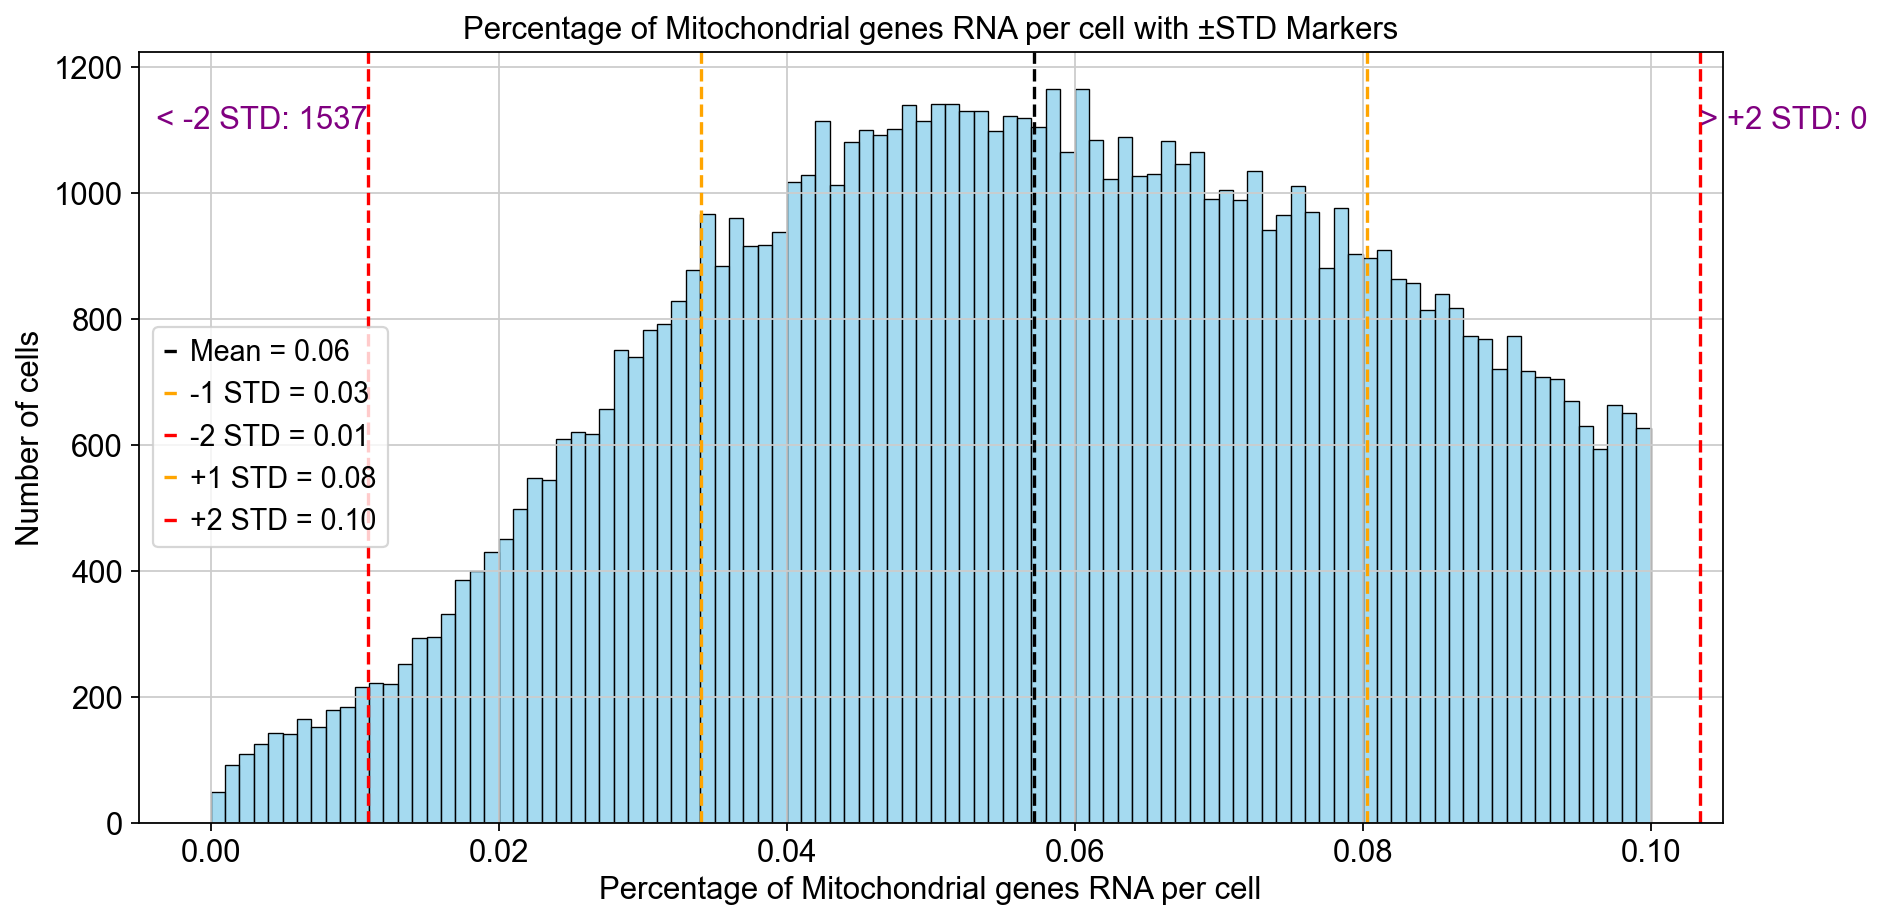

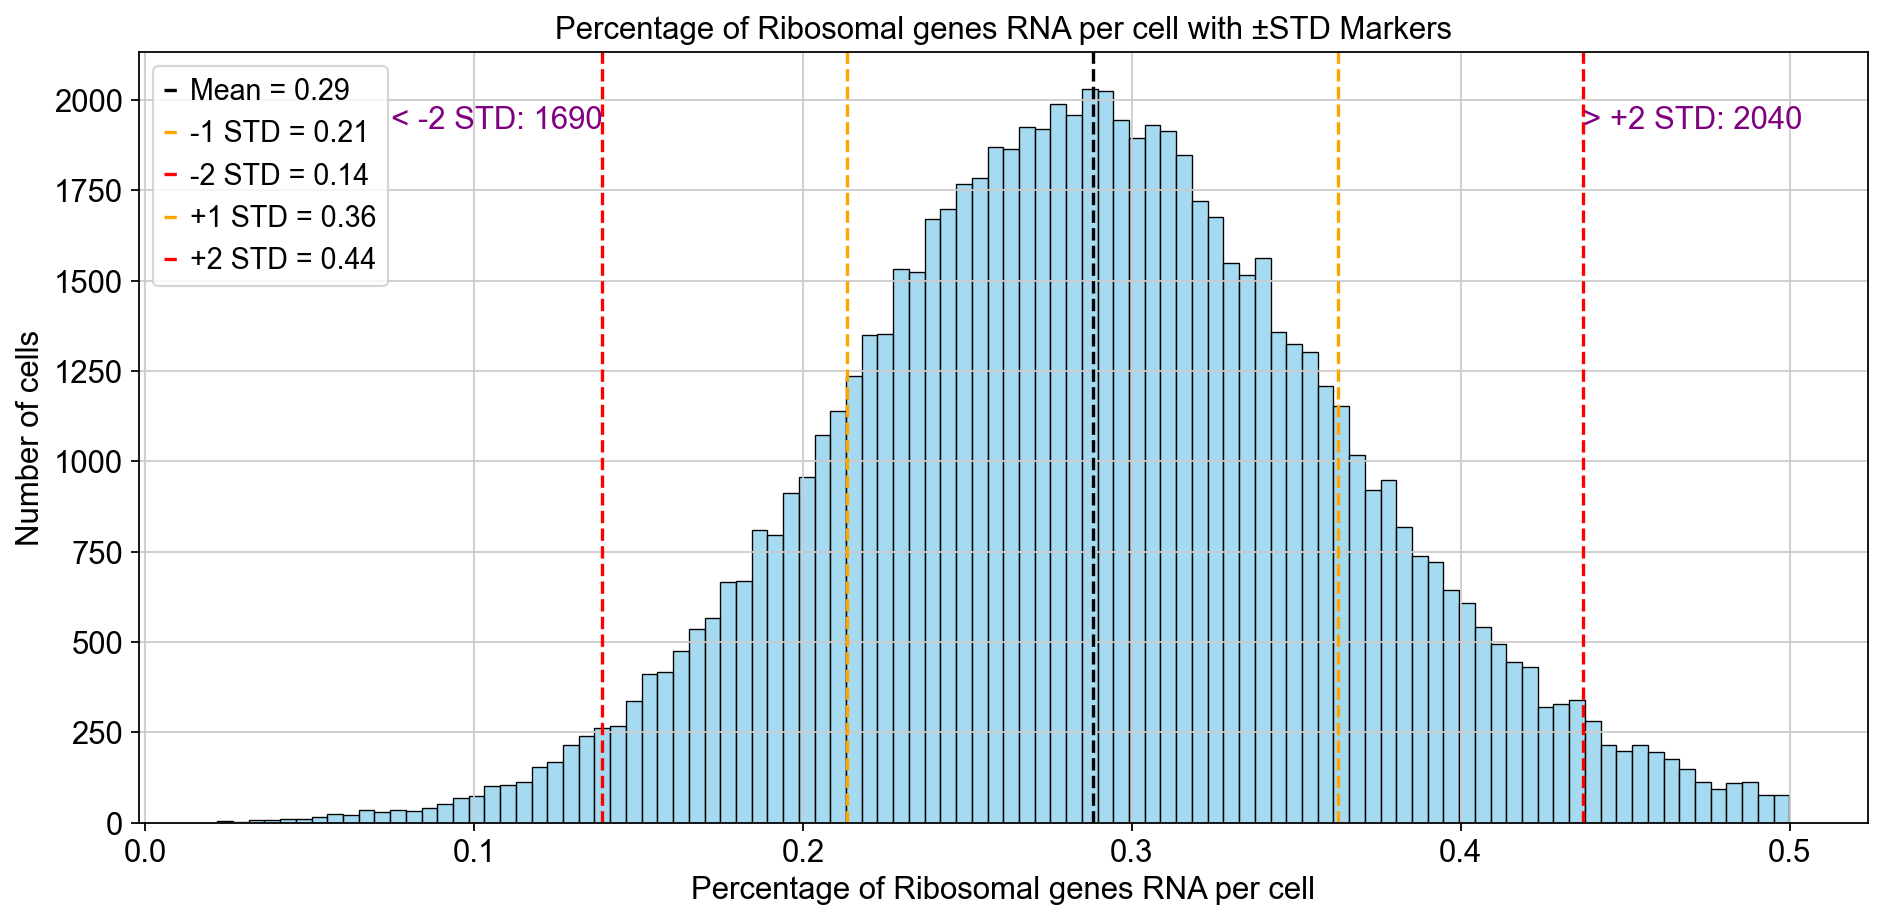

In [12]:


sc.pp.calculate_qc_metrics(adata, inplace=True)


# Get the data
n_genes_by_counts = adata.obs['n_genes_by_counts']
create_hist(n_genes_by_counts,xlabel='Number of genes per cell',ylabel='Number of cells',title='Gene Count Distribution per Cell with ±STD Markers')

total_counts = adata.obs['total_counts']
create_hist(total_counts,xlabel='Total RNA counts per cell',ylabel='Number of cells',title='Total RNA counts per cell with ±STD Markers')

mito_pct = adata.obs['percent_mito']
create_hist(mito_pct,xlabel='Percentage of Mitochondrial genes RNA per cell',ylabel='Number of cells',title='Percentage of Mitochondrial genes RNA per cell with ±STD Markers',bins=100)

rb_pct = adata.obs['percent_rb']
create_hist(rb_pct,xlabel='Percentage of Ribosomal genes RNA per cell',ylabel='Number of cells',title='Percentage of Ribosomal genes RNA per cell with ±STD Markers',bins=100)


In [ ]:
plot_categorical_distribution(adata, 'cell_type')
# answer = llm_instance.ask("what can u say about the distribution of the cell types in my data? {}".format(adata.obs['cell_type'].value_counts()))
# print(answer)

**How much between-donor heterogeneity is there in the cell type abundance?**

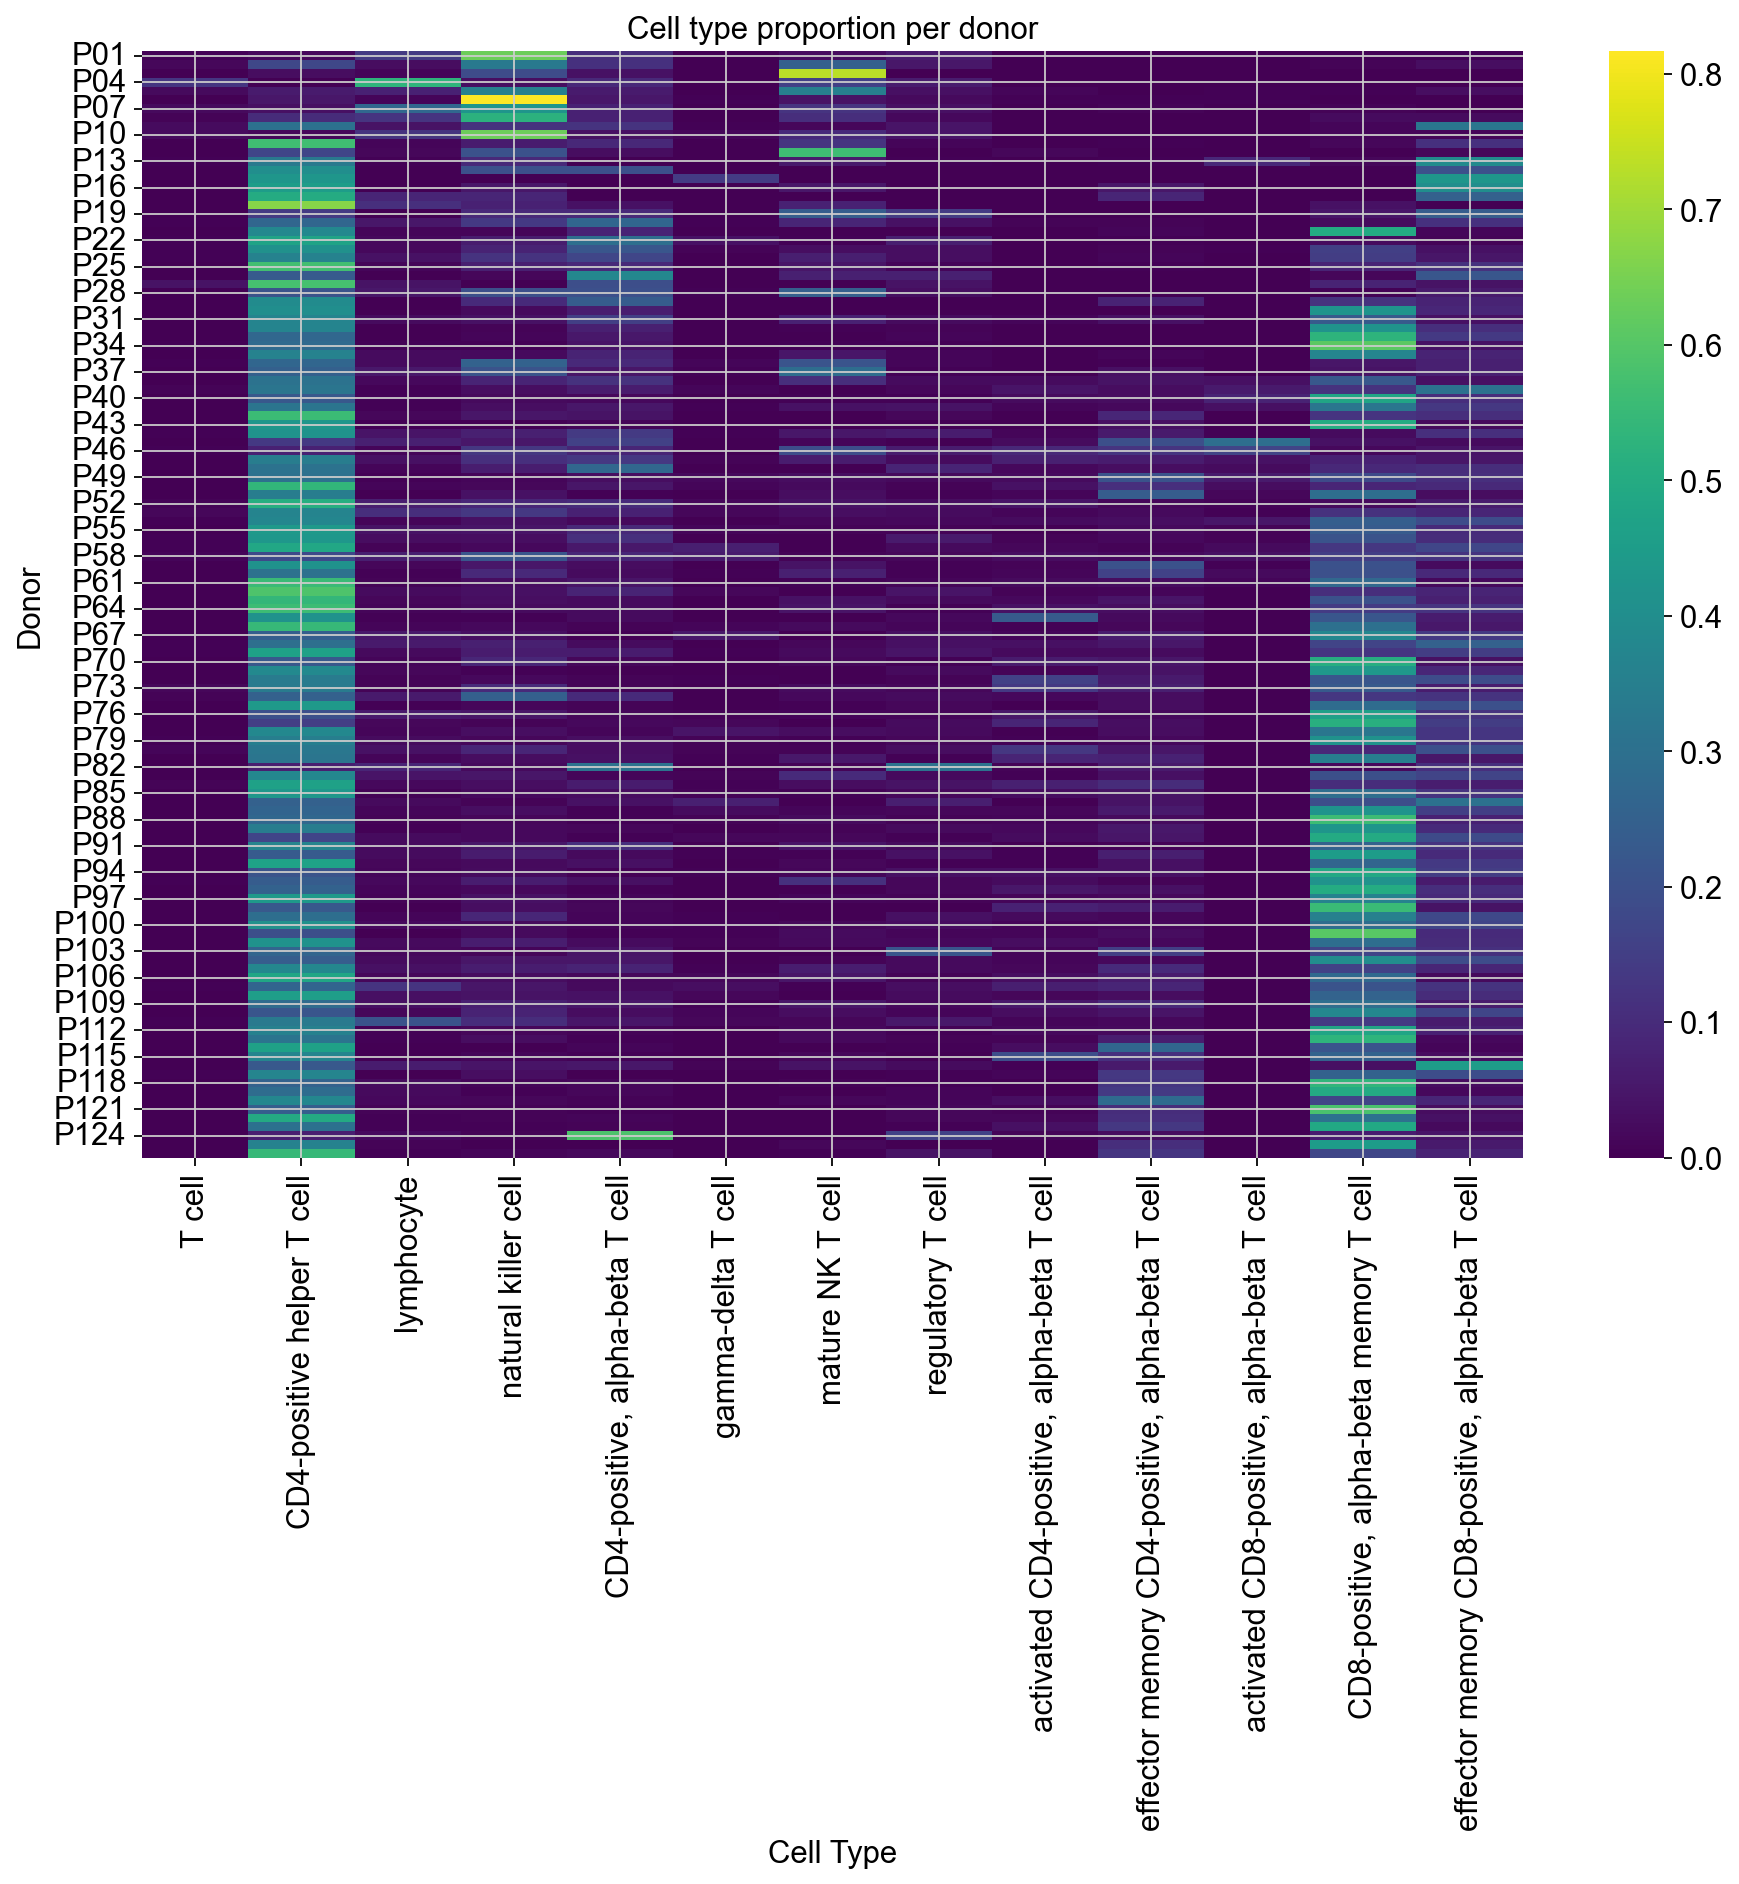

In [49]:
## between-donor heterogeneity in cell type abundance
# Create donor × cell_type count matrix
donor_celltype_counts = pd.crosstab(adata.obs['donor_id'], adata.obs['cell_type'])
donor_celltype_counts.head()
donor_celltype_freq = donor_celltype_counts.div(donor_celltype_counts.sum(axis=1), axis=0)

plot_heatmap(donor_celltype_freq, xlabel="Cell Type", ylabel="Donor", title="Cell type proportion per donor")

# answer = llm_instance.ask("in my dataset, the between-donor heterogeneity in cell type abundance is {}. what can I learn from this?".format(donor_celltype_freq))
# print(answer)



**Distribution and Batch effect identification**

In [ ]:
# ARI Value	Meaning, to help identify batch effects
#  ~0.0	Little to no overlap between clusters and column → minimal batch effect
#  ~0.3–0.5	Moderate overlap — some batch structure may exist
# >0.6–1.0	Clusters strongly align with column → strong batch effect present

categroical_meta_columns = ['cell_type','author_cell_type','assay','reported_diseases','development_stage','age_group','bmi_group','cell_state','sample_source',\
    'procedure_group','breast_density','sequencing_platform','suspension_dissociation_time','tissue_location']
for col in categroical_meta_columns:
    plot_categorical_distribution(adata, col)
    sc.pl.pca(adata, color=col)
    calc_batch_effect_score(adata,col)
    
for col in ['sample_id', 'donor_id']:
    calc_batch_effect_score(adata,col)
    
##Lets check if a specific category tends to be imblanced and if it create batch effect and tends to locate in a specific area in the UMAP 
##From ARI we learned that there a batch effect in the assay column (ARI 0.21) but the most dominant variable is the cell type!   


In [ ]:
##NEW
#Show number of samples per donor check that it distribute across many donors

# Ensure both columns exist
if 'sample_id' in adata.obs.columns and 'donor_id' in adata.obs.columns:
    samples_per_donor = adata.obs[['sample_id', 'donor_id']].drop_duplicates()
    count_per_donor = samples_per_donor.groupby('donor_id').size().sort_values(ascending=False)

    print(count_per_donor)
else:
    print("Missing 'sample_id' or 'donor_id' in adata.obs")

**Are there big differences in effect from samples from different `assay` types?**

We first evaluated whether the assay metadata contributes to batch effects, and found evidence of such impact, From ARI we learned that there a 

batch effect in the assay column (ARI 0.21) but the most dominant variable is the cell type.

The 10X 3' v3 assay tends to detect a higher number of genes per cell, all assays consistently capture the full range of cell types. Although the abundance of certain cell 

types varies across assays, no cell type is exclusive to a particular assay.

<Axes: xlabel='assay', ylabel='n_genes_by_counts'>

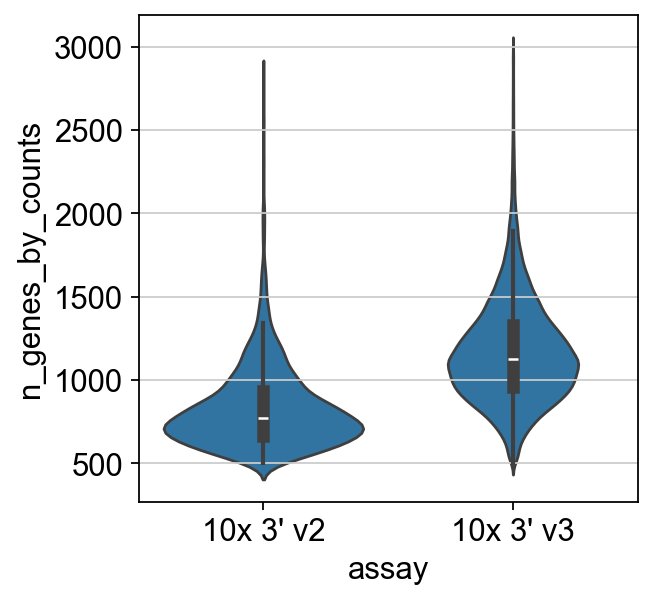

In [19]:
sns.violinplot(data=adata.obs, x='assay', y='n_genes_by_counts')

## We can see that 10X 3' V3 tends to detect more genes

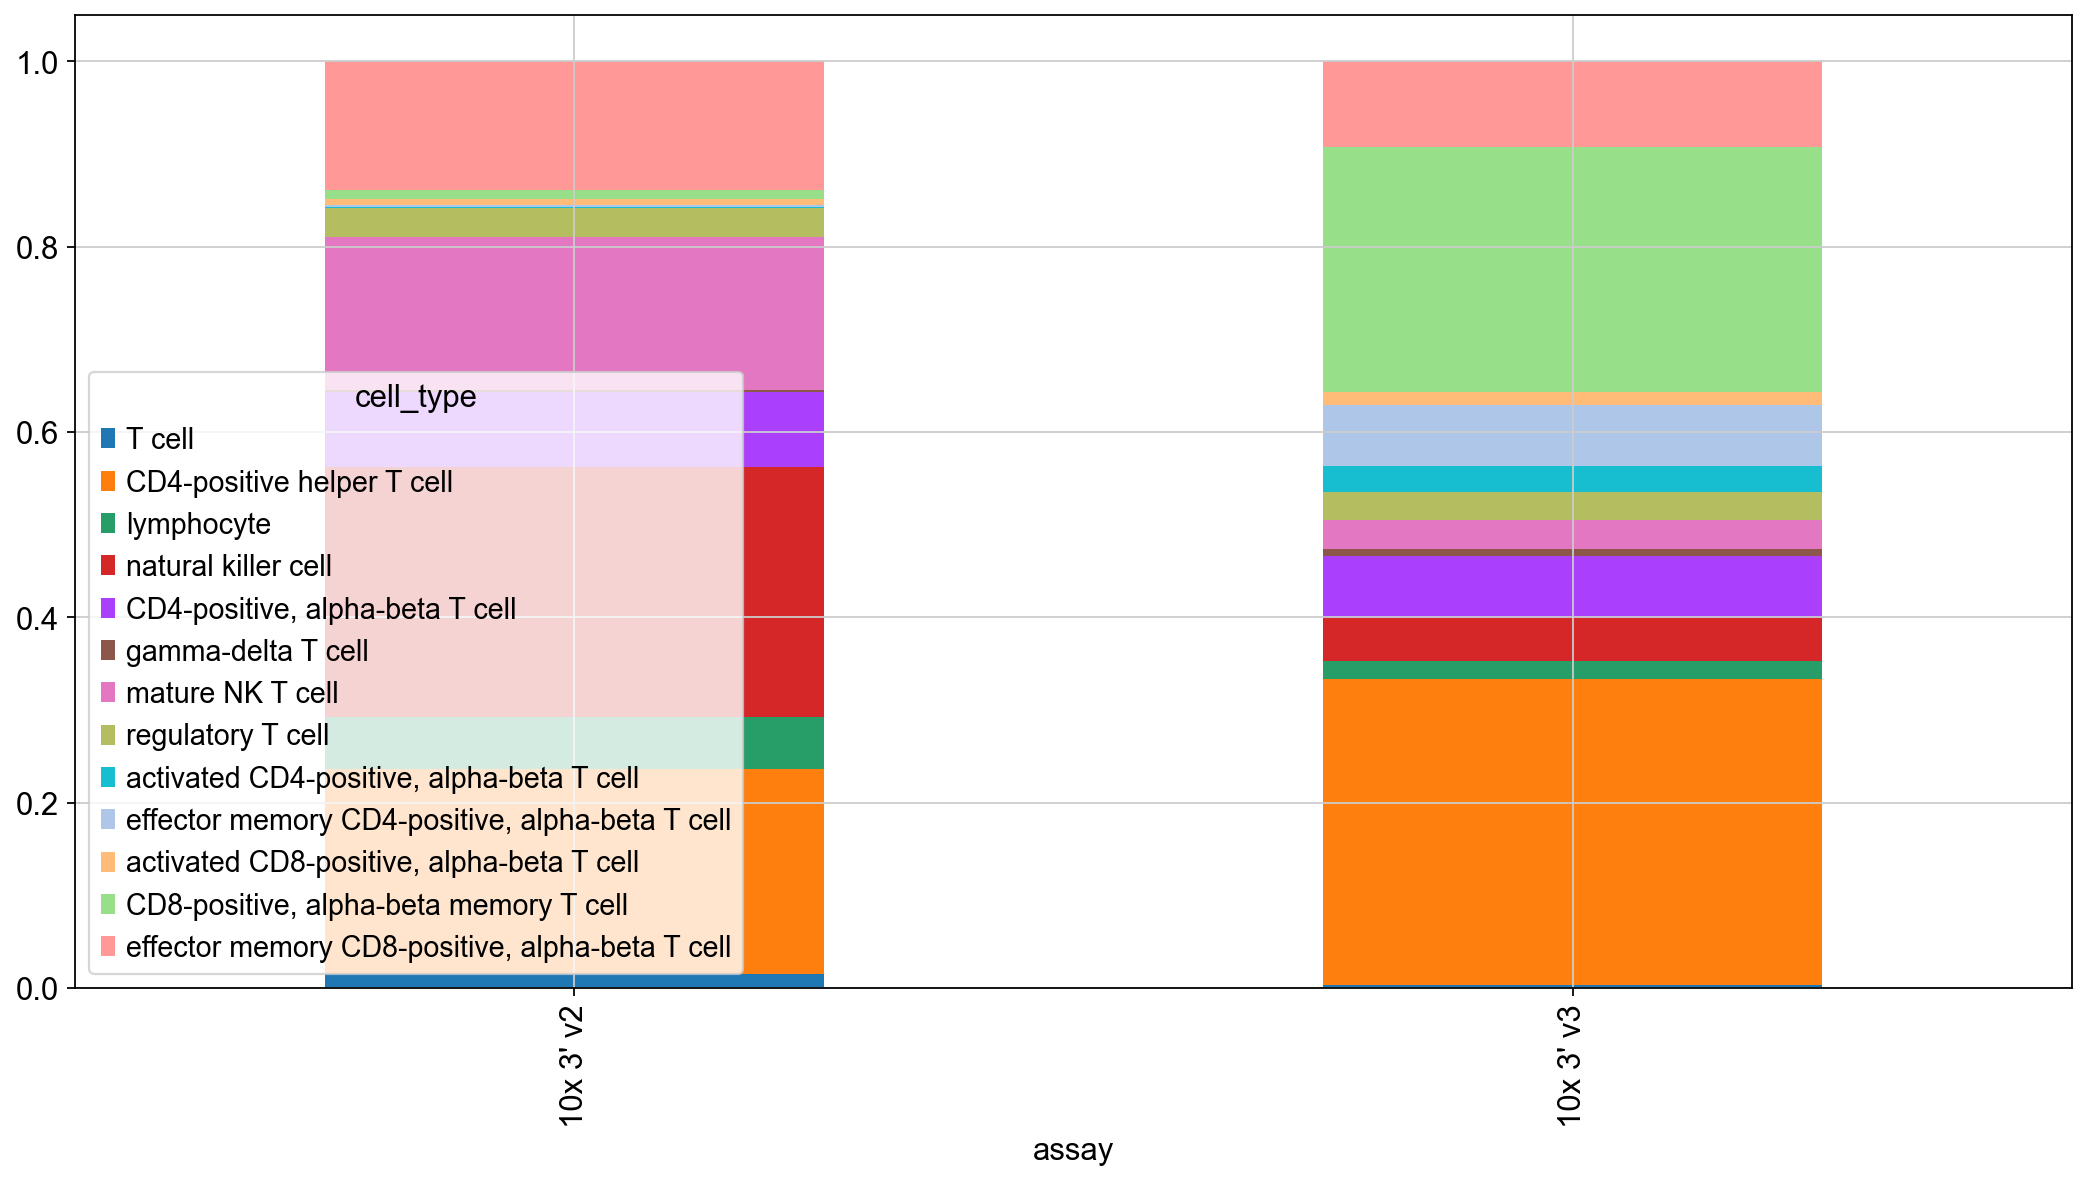

In [ ]:
plot_bar_comaprision(adata, "cell_type","assay")


## Latent single-cell representation

Single-cell represenation is an important part of any single-cell analysis. There are many approaches, from simple PCA to batch-correcting algos on top of PCA (e.g.,[Harmony](https://github.com/lilab-bcb/harmony-pytorch)) to VAEs (e.g., [scVI](https://scvi-tools.org/)) to even much more recent Transformer-based approaches (e.g,. [Geneformer](https://huggingface.co/ctheodoris/Geneformer)). 

In this exercise you will build an autoencoder (not a VAE) to represent the cells. 
Challenges we'd like you to address: how can you get rid of the batch effect from the technology("assay" column)? can you use the cell_type as signal? 
Think about the right loss function / functions, network structure.
Steps:
1. Clean up the data
2. Choose highly variable genes (don't take more than 2,000)
3. Train you network
4. Evaluate the network
5. Compare to PCA

This isn't easy, your network should converge but it's totally fine if it doesn't beat PCA.
How would you improve it if you had 3 months?

In [39]:
adata = ad.read_h5ad('./data/dataset.h5ad')
adata.shape
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Clean data
print("Before:", adata.shape)
min_genes = 500   # 2 STD are 590, choose 500, like in Kumar et al -> remove empty/low-quality cells
sc.pp.filter_cells(adata, min_genes=min_genes)

min_cells = 3   # Role of thumb
sc.pp.filter_genes(adata, min_cells=min_cells)

max_genes = 3000             # 2 STD are 2638 -> remove potential doublets
sc.pp.filter_cells(adata, max_genes=max_genes)

max_counts = 20000   
adata = adata[adata.obs['total_counts'] < max_counts, :] #cells expressing more than 20,000 UMIs like in kumar et al

## Cells with higher than 10% mitochondrial or 50% ribosomal transcripts were already filtered 

print("After:", adata.shape)

Before: (76567, 33145)
filtered out 738 cells that have less than 500 genes expressed
filtered out 9772 genes that are detected in less than 3 cells
filtered out 98 cells that have more than 3000 genes expressed
After: (75731, 23373)


In [40]:
## Normalize data
#Total-count normalize (library-size correct) the data matrix to 10,000 reads per cell
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


c:\Users\Lionb\anaconda3\envs\imunnai\Lib\site-packages\scanpy\preprocessing\_normalization.py:216: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:01)


In [41]:
# Get only 2000 high variable genes
sc.pp.highly_variable_genes(adata, batch_key='assay', n_top_genes=2000)
cdata = adata[:, adata.var.highly_variable]

print("After high variable genes selection:", cdata.shape)

extracting highly variable genes
    finished (0:00:11)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
After high variable genes selection: (75731, 2000)


c:\Users\Lionb\anaconda3\envs\imunnai\Lib\site-packages\scanpy\preprocessing\_qc.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics


normalizing counts per cell
    finished (0:00:00)


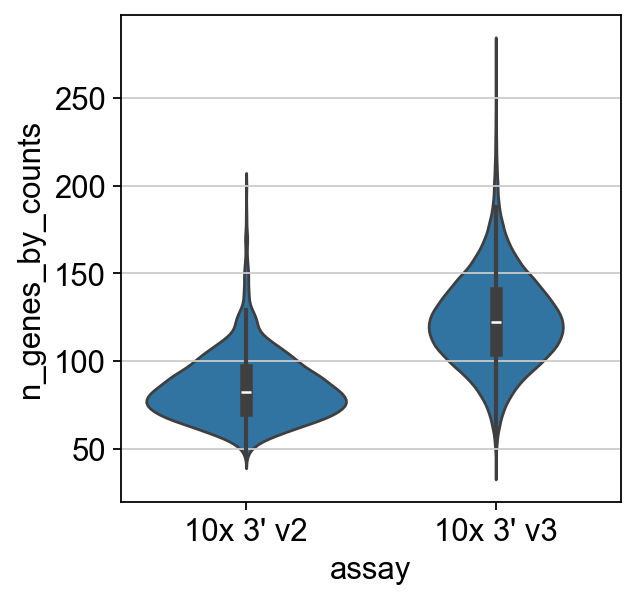

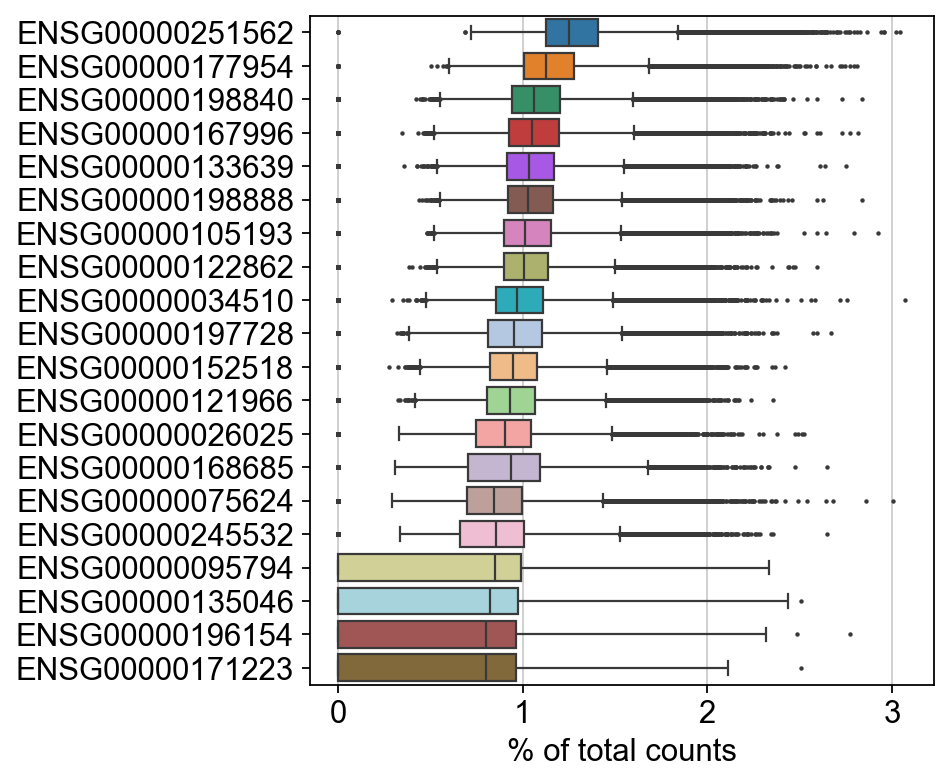

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


,ensembl.gene,name
0,ENSG00000251562,metastasis associated lung adenocarcinoma tran...
1,ENSG00000166710,beta-2-microglobulin
2,ENSG00000177954,ribosomal protein S27
3,ENSG00000167526,ribosomal protein L13
4,ENSG00000137818,ribosomal protein lateral stalk subunit P1
5,ENSG00000147403,ribosomal protein L10
6,ENSG00000229117,ribosomal protein L41
7,ENSG00000198804,cytochrome c oxidase subunit I
8,ENSG00000133112,"tumor protein, translationally-controlled 1"
9,ENSG00000198938,cytochrome c oxidase subunit III


In [42]:
sc.pp.calculate_qc_metrics(cdata, inplace=True)
sns.violinplot(data = cdata.obs, x='assay', y='n_genes_by_counts')

##We can see that still 10x 3' v3 has more genes to sample after the filtering but the margin has decreased.

##Plot highest expressed genes
sc.pl.highest_expr_genes(cdata, n_top=n_top)

# Query multiple genes and request GO terms + summary + pathways
annotations = gene_info_instance.query_genes(top_genes,return_info='name,symbol')#'go.summary,pathway,summary')
results_df = gene_info_instance.parse_results(annotations)
results_df[['ensembl.gene','name']].head(n_top)

In [43]:
##Scale and recalculate PCA
sc.pp.pca(cdata,n_comps=50) #Use the ARPACK algorithm, which is optimized for: Sparse matrices, Large datasets (like in scRNA-seq)
sc.pp.neighbors(cdata)
sc.tl.umap(cdata)
print("Sum variance ratio:", cdata.uns['pca']['variance_ratio'][:50].sum())

computing PCA
    with n_comps=50
    finished (0:00:05)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:12)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:54)
Sum variance ratio: 0.26844808


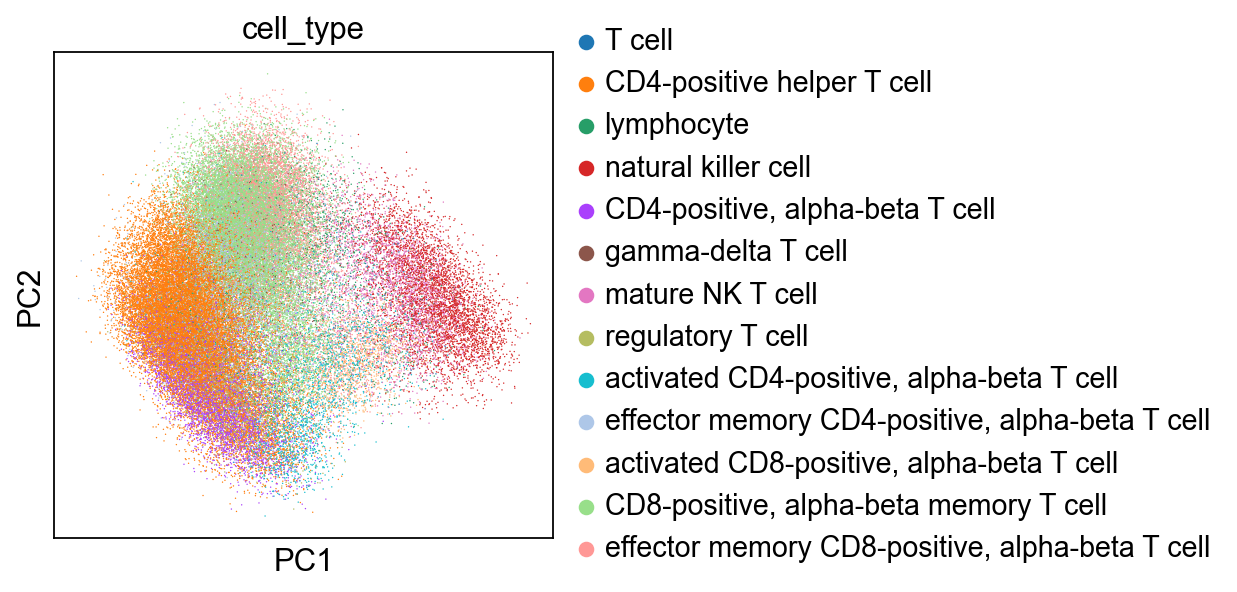

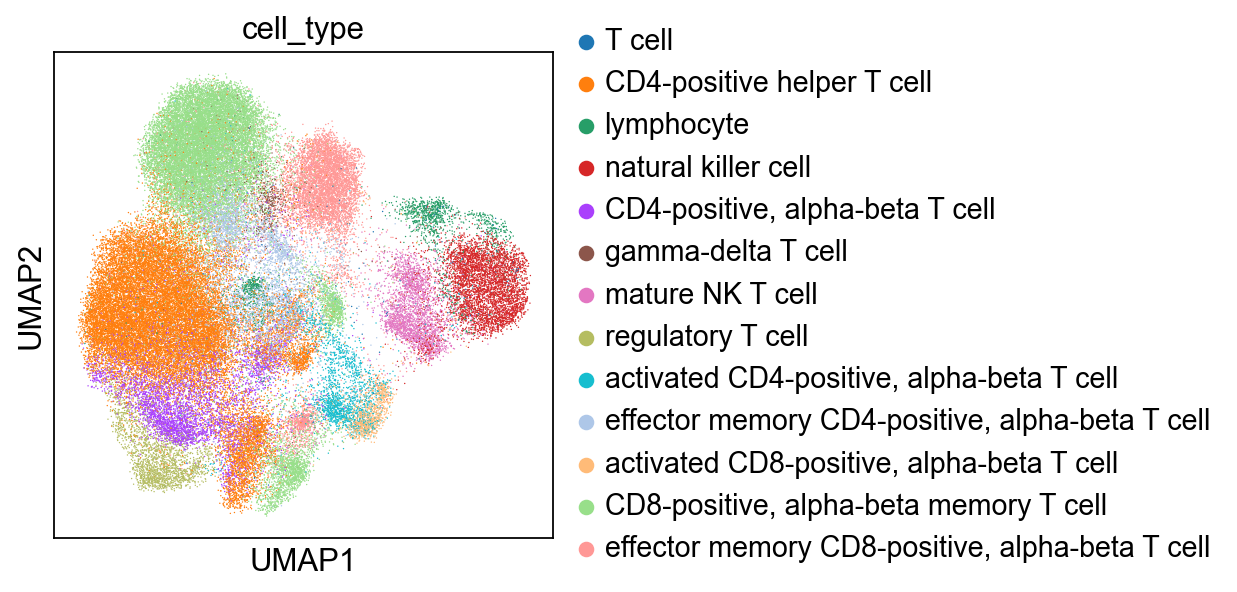

ARI between KMeans clusters and 'cell_type': 0.2878


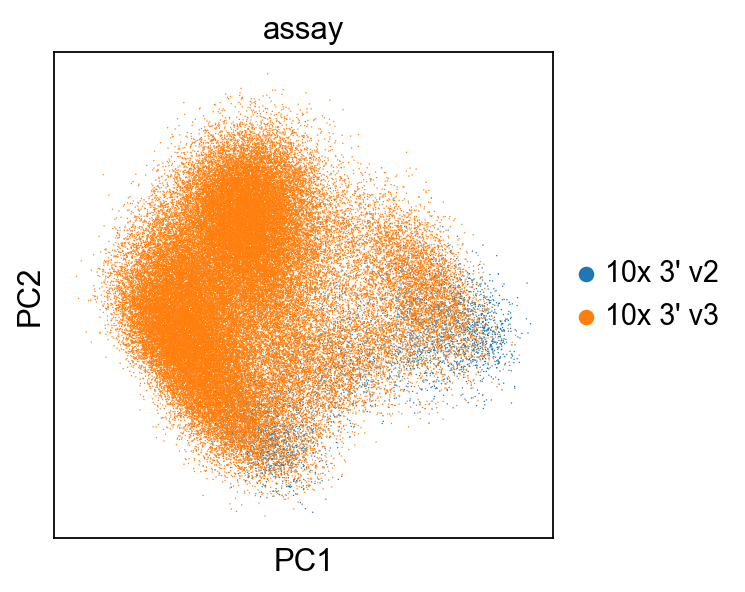

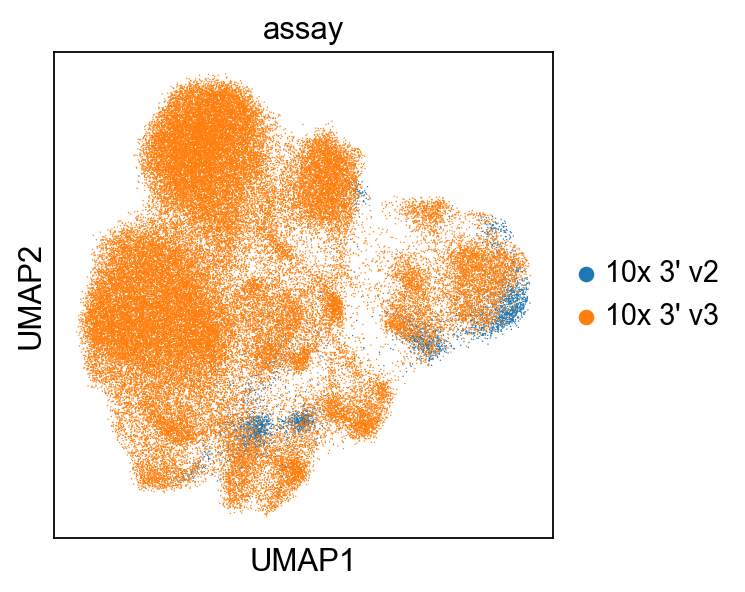

ARI between KMeans clusters and 'assay': 0.2058


In [ ]:
## Check assay batch effect now after normalizing and filtering
for col in ['cell_type','assay']:
    # plot_categorical_distribution(cdata, col)
    sc.pl.pca(cdata, color=col)
    sc.pl.umap(cdata, color=col)
    calc_batch_effect_score(cdata,col)
    
#We can see that the filering and normalization reduced a bit the batch effect but resuced a lot the signal of the cell type, this is not a good result.

2025-04-09 10:44:31,489 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-09 10:44:49,929 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-09 10:44:50,782 - harmonypy - INFO - Iteration 1 of 50
2025-04-09 10:46:29,015 - harmonypy - INFO - Iteration 2 of 50
2025-04-09 10:47:53,439 - harmonypy - INFO - Iteration 3 of 50
2025-04-09 10:49:33,921 - harmonypy - INFO - Converged after 3 iterations


computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:23)


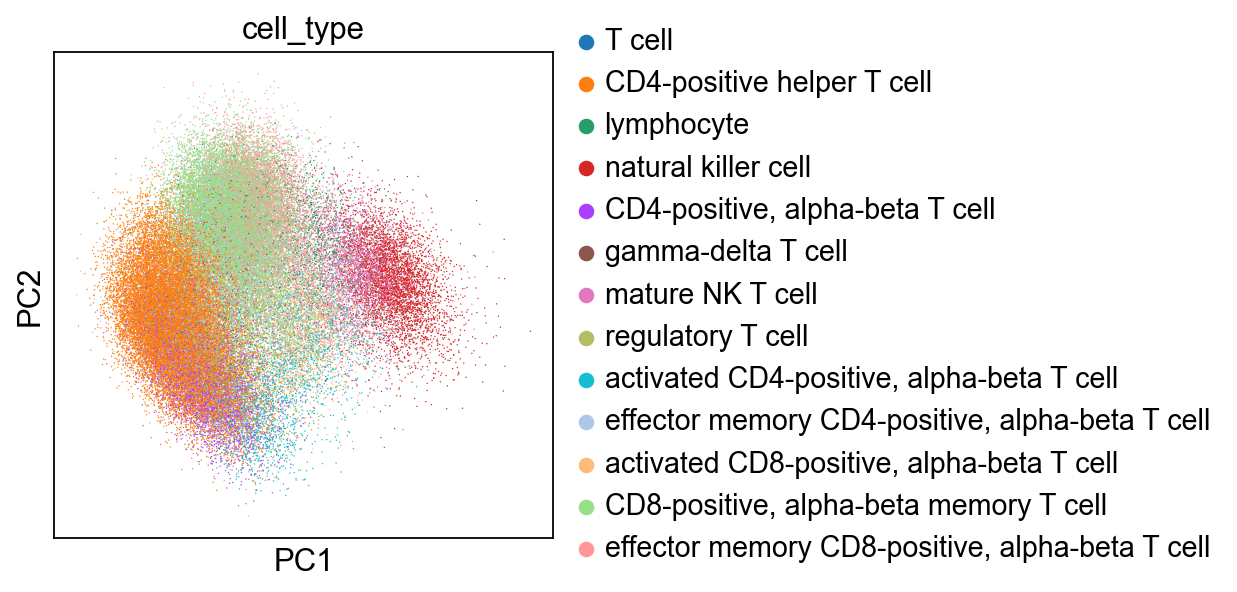

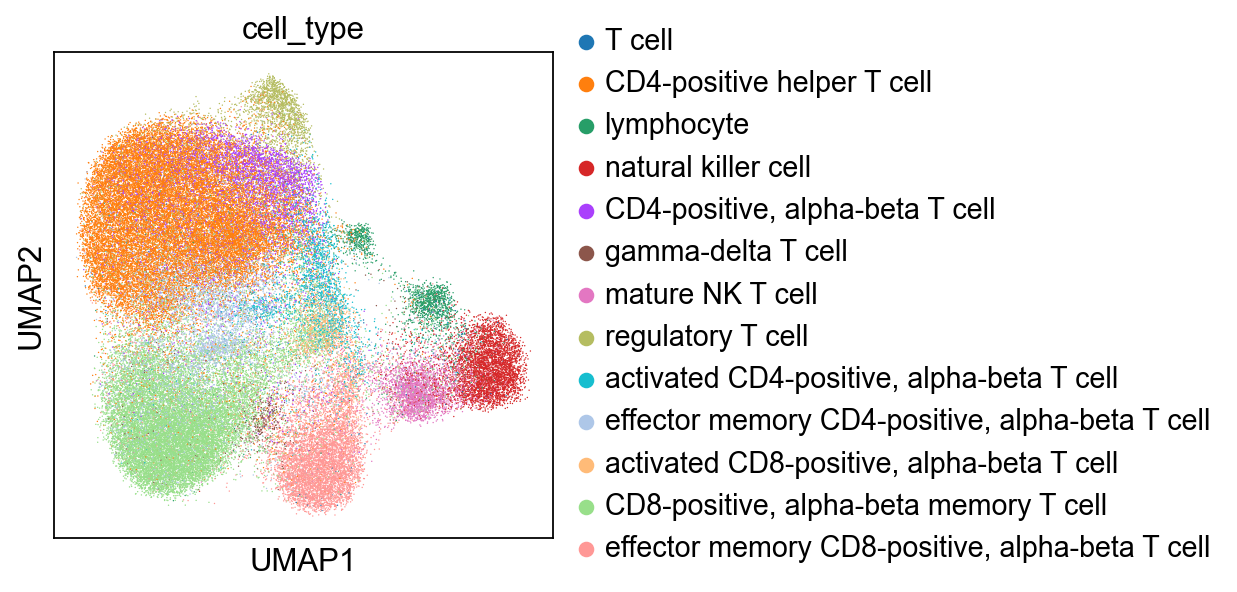

ARI between KMeans clusters and 'cell_type': 0.2901


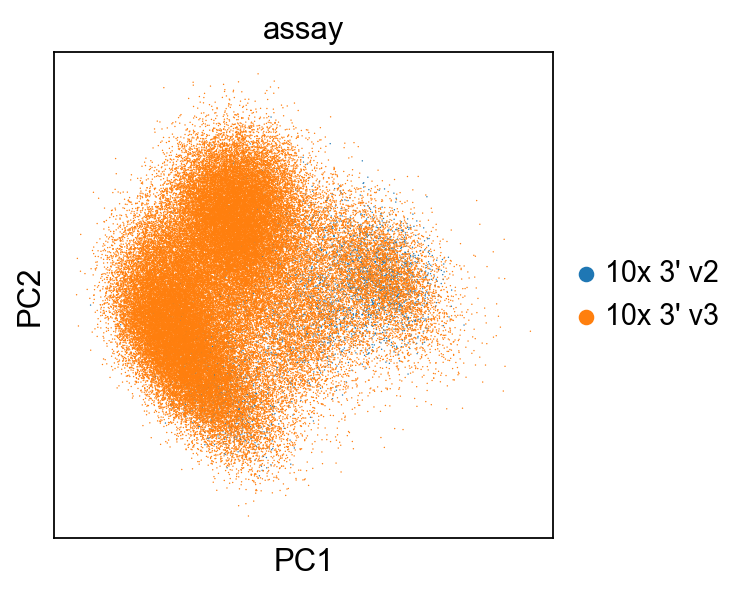

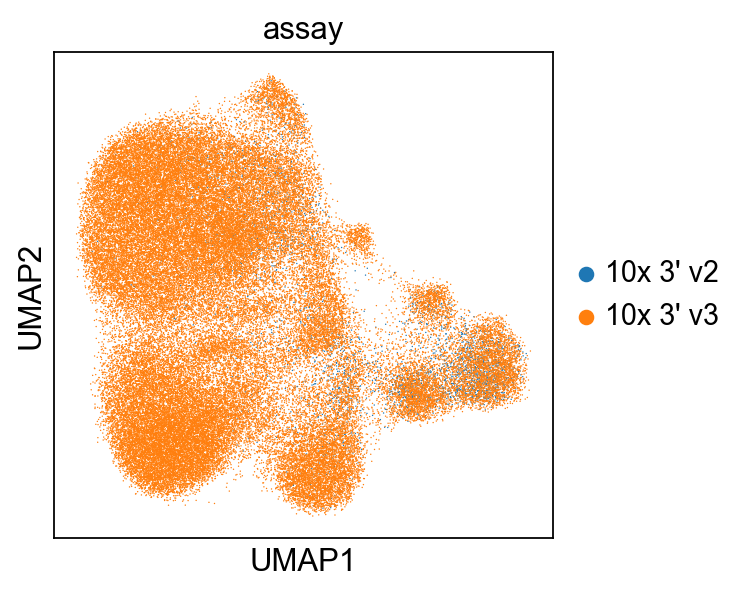

ARI between KMeans clusters and 'assay': 0.0011


In [ ]:
##Run Harmony integration batch effect correction
import scanpy.external as sce
sce.pp.harmony_integrate(cdata, key='donor_id',max_iter_harmony=50)
cdata.obsm['X_pca'] = cdata.obsm['X_pca_harmony']

sc.pp.neighbors(cdata)
sc.tl.umap(cdata)

for col in ['cell_type','assay']:
    # plot_categorical_distribution(cdata, col)
    sc.pl.pca(cdata, color=col)
    sc.pl.umap(cdata, color=col)
    calc_batch_effect_score(cdata,col)
    
#Harmony does good job at mainting the cell type fator in the data and mixing the assay factor, this will be our benchmark for comparison.


In [48]:
    import torch
    from model import Autoencoder
    from train import get_dataloader, train_model
    from utils import convert_to_dense_torch
    
    input_dim = adata.shape[1]
    print(f"Input dimension (number of genes): {input_dim}")
    
    model = Autoencoder(input_dim, latent_dim=64, hidden_dims=[512,256,128], dropout_prob=0.2)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Training on device:", device)
    
    dataloader = get_dataloader(adata, batch_size=64, device=device)
    
    # Train the model
    model = train_model(model, dataloader, epochs=1, lr=0.001, device=device)
    
    # Save the model parameters
    # torch.save(model.state_dict(), args.output_model)
    # print("Model saved to:", args.output_model)
    
    # Optionally, extract the latent space and store it in adata for further analysis.
    model.eval()
    with torch.no_grad():
        _, latent = model(convert_to_dense_torch(adata, device))
        adata.obsm["X_autoencoder"] = latent.cpu().numpy()

Input dimension (number of genes): 23373
Training on device: cpu
Epoch 1/1 - Loss: 0.1498


## Predicting disease state from your latent representation.

Now that you have a decent latent representation, define
1) Train/test split based on `donor_id`
2) Classificaton task and performance metric based on `disease`
3) Set of classifiers you want to try for this task (logistic regression and XGBoost are good lightweight places to start, but you're welcome to use and explore others as well).
4) Compare the PCA and AE latent representations, which is better for the classification task?

In this section, train your classifiers and report and discuss your performance metrics. A few questions to guide your discussion:
- How well do you do compared to a random/dummy classifier?
- How much overfitting are your seeing? How much did regularization help?
- What else would you try if you had (or wanted to spend) more time on this assignment?

In [ ]:
# Put your code, figures, and interpretation here.

In [ ]:
#import xgboost as xgb 
#or use any other classifier, we recommend not to go deep
